<a href="https://colab.research.google.com/github/anikatahsinislam76/diabetes-risk-classification/blob/main/diabetes_risk_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Risk Classification Using Machine Learning

### A Health Data Science Portfolio Project

This project explores the use of machine learning techniques to classify diabetes risk using the Pima Indians Diabetes Dataset.

The analysis focuses not only on predictive performance but also on clinically relevant evaluation metrics such as sensitivity, false-negative rate and ROC-AUC.

The project includes data auditing, preprocessing, exploratory data analysis, leakage-aware modelling, threshold analysis, cross-validation and comparison of multiple machine learning algorithms.

 Project Objective

The main objective of this project is to develop and evaluate machine learning models for diabetes risk classification.

The project specifically aims to:

- examine the quality and structure of the dataset
- identify and handle hidden missing values
- explore relationships between clinical variables and diabetes outcome
- build a leakage-aware machine learning pipeline
- compare Logistic Regression, Random Forest and Support Vector Machine models
- evaluate model performance using clinically relevant metrics
- examine the trade-off between sensitivity and specificity

  Dataset Description

The analysis uses the Pima Indians Diabetes Dataset.

The dataset contains 768 observations and 9 variables.

The predictor variables include:

- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- Diabetes Pedigree Function
- Age

The target variable is Outcome:

- 0 = Non-Diabetic
- 1 = Diabetic

This is therefore a binary classification problem.

# Loading Dataset

In [ ]:
import numpy as np
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

df = pd.read_csv(url)
print("Dataset Shape", df.shape)

print("n/Column names:")
print(df.columns.tolist())

df.head()

Dataset Shape (768, 9)
n/Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Data types, missing values, duplicate data and statistical **analysis**

In [ ]:
#Data types and non-null counts
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#counting missing values
print("\nMissing values per column:")
print(df.isnull().sum())

#Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

#statistical details'
df.describe()


Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Check class distribution of the target variable

In [ ]:
#Count each outcome
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


# Calculate percent distrubution of each outcome

In [ ]:
#Percentage distribution
print(
    (df["Outcome"].value_counts(normalize= True) * 100)
)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


# Check any invalid number present except 0 and 1

In [ ]:
#Check invalid Target values
print("UNique target values:", df["Outcome"].unique())

UNique target values: [1 0]


# Check the data distribution through visualization

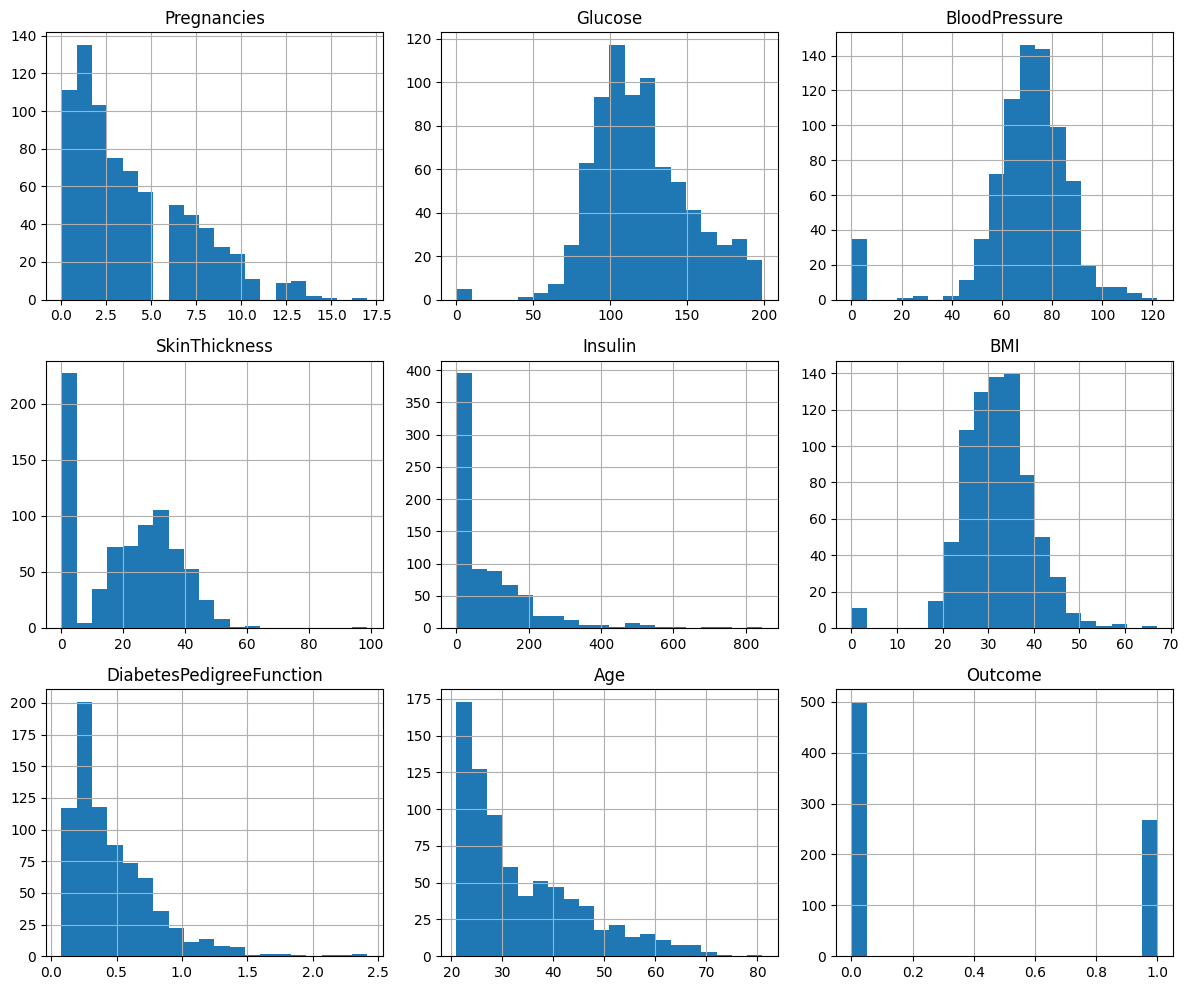

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize= (12,10), bins= 20)
plt.tight_layout()
plt.show()


# The primary audit before any pre processing of values

In [ ]:
audit = pd.DataFrame({
    "dtype" : df.dtypes.astype(str),
    "missing values": df.isnull().sum(),
    "zero values": (df == 0).sum(),
    "unique values" : df.nunique()
})

audit


,dtype,missing values,zero values,unique values
Pregnancies,int64,0,111,17
Glucose,int64,0,5,136
BloodPressure,int64,0,35,47
SkinThickness,int64,0,227,51
Insulin,int64,0,374,186
BMI,float64,0,11,248
DiabetesPedigreeFunction,float64,0,0,517
Age,int64,0,0,52
Outcome,int64,0,500,2


# Collecting the columns where zero or invalid data is present

In [ ]:
#Columns where zero means invalid/missing

zero_invalid_cols = [
    'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'
]

#Replace invalid  zero values with NaN
df[zero_invalid_cols] = df[zero_invalid_cols].replace(0, np.nan)

#Check missing values again
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


# Calculate the percentage of missing value present in data

In [ ]:
#missing value percentage

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Value Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Values,Missing Value Percentage
Pregnancies,0,0.000000
Glucose,5,0.651042
BloodPressure,35,4.557292
SkinThickness,227,29.557292
Insulin,374,48.697917
BMI,11,1.432292
DiabetesPedigreeFunction,0,0.000000
Age,0,0.000000
Outcome,0,0.000000


# Filling the missing values with median

In [ ]:
for col in zero_invalid_cols:
  df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


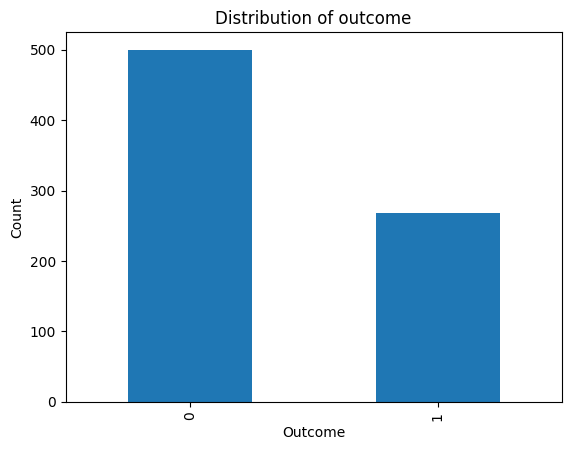

In [ ]:
df['Outcome'].value_counts().plot(kind = 'bar')

plt.title('Distribution of outcome')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

# Checking the distribution via visualization again after feature engineering

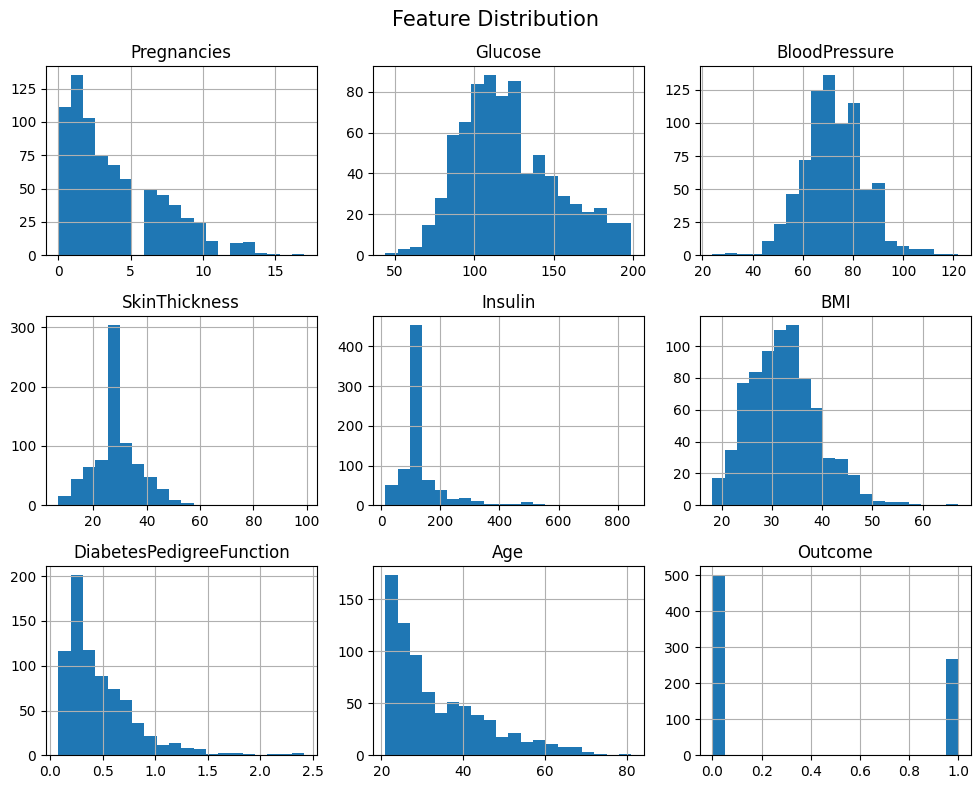

In [ ]:
df.hist(figsize=(10,8), bins= 20)
plt.suptitle('Feature Distribution', fontsize= 15)
plt.tight_layout()
plt.show()

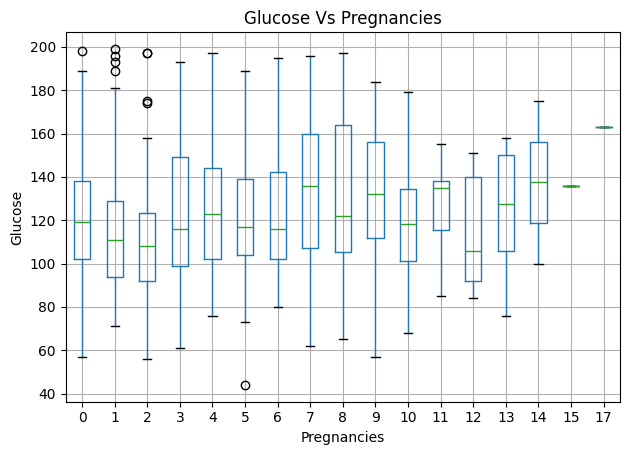

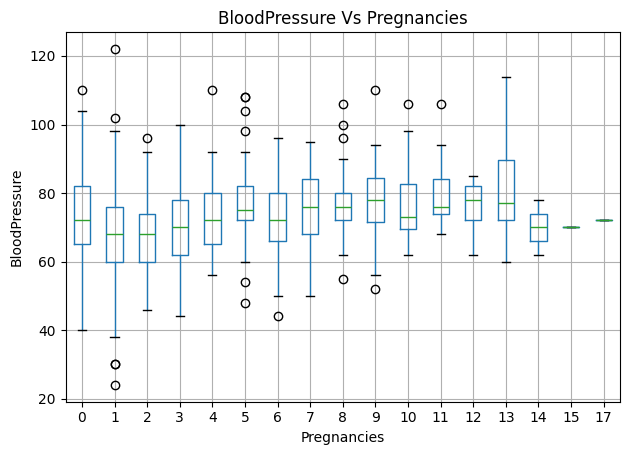

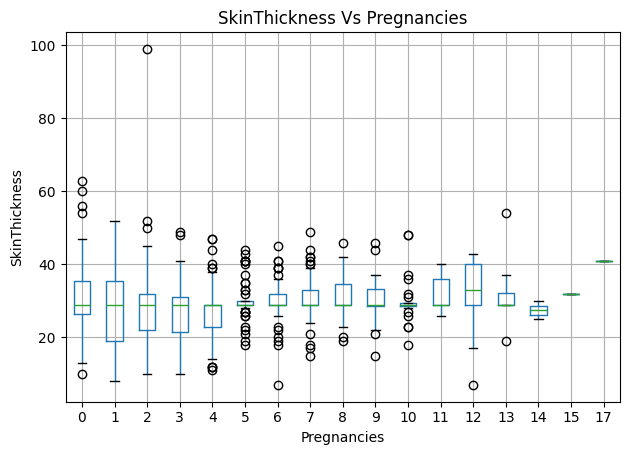

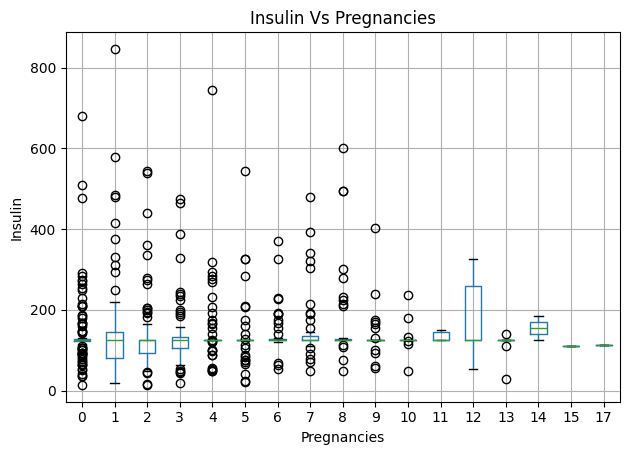

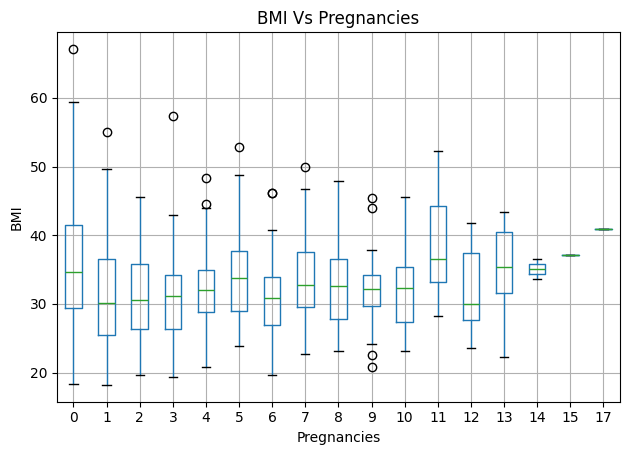

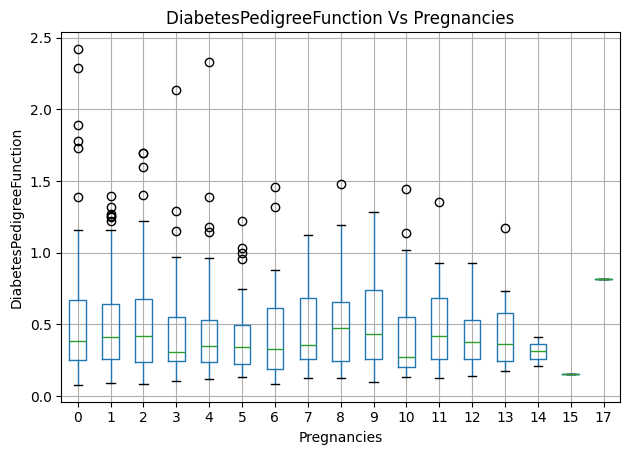

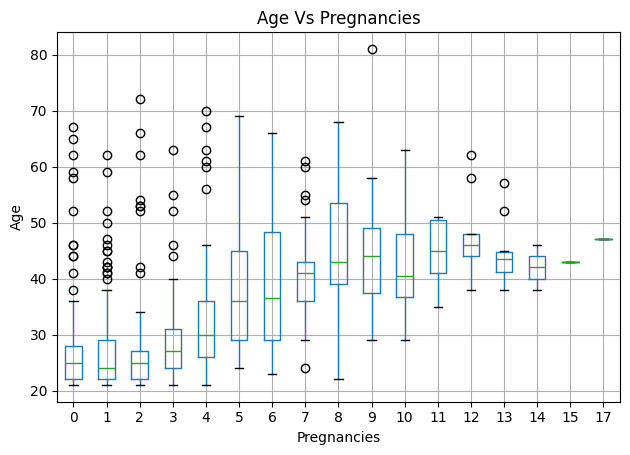

In [ ]:
important_feature = [
   'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

for col in important_feature:
  df.boxplot(column = col, by= 'Pregnancies')
  plt.title(f'{col} Vs Pregnancies')
  plt.suptitle('')
  plt.xlabel('Pregnancies')
  plt.ylabel(col)
  plt.tight_layout()
  plt.show()



# Comparing and finding the outliers of every variable from boxplot against outcome

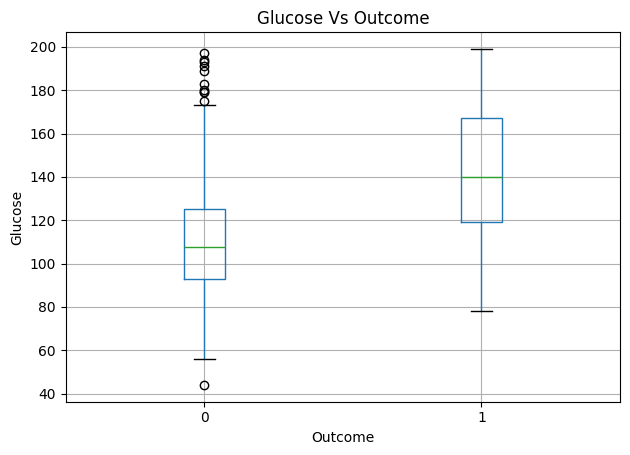

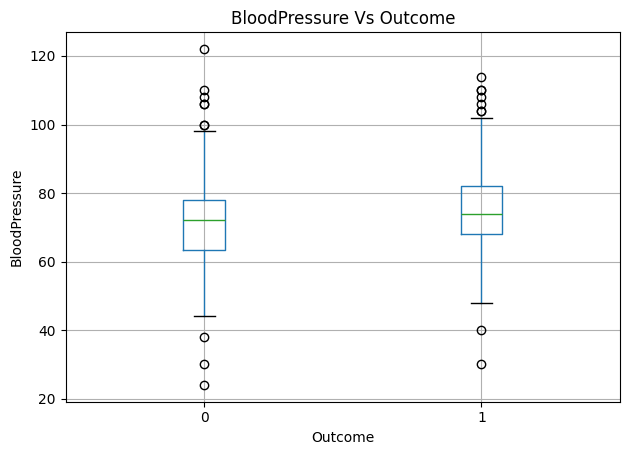

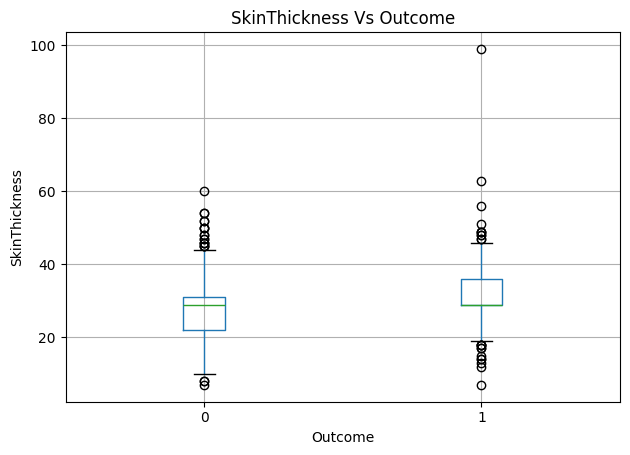

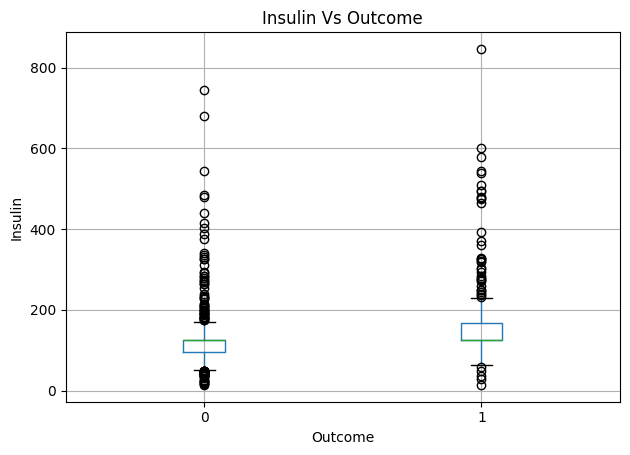

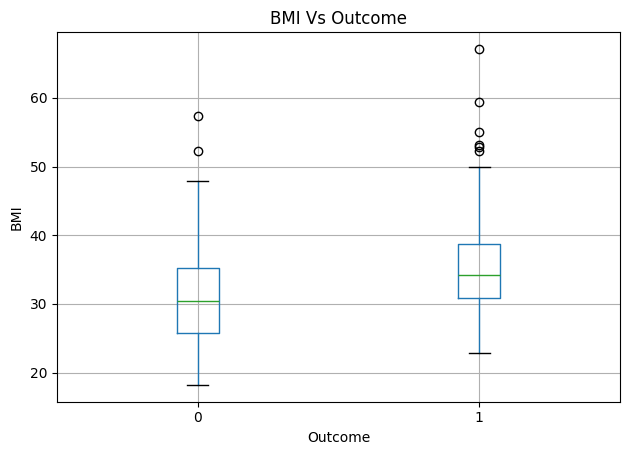

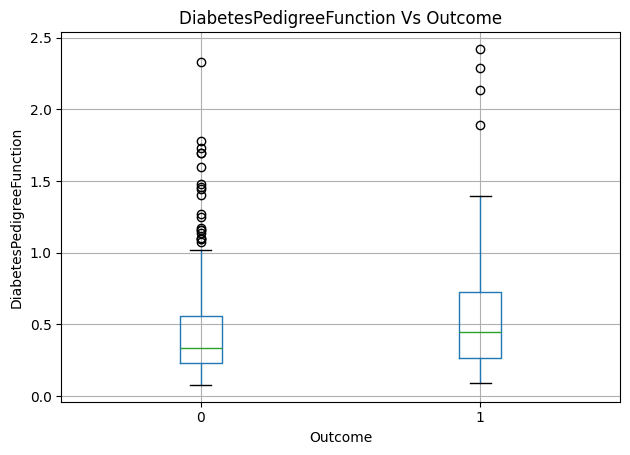

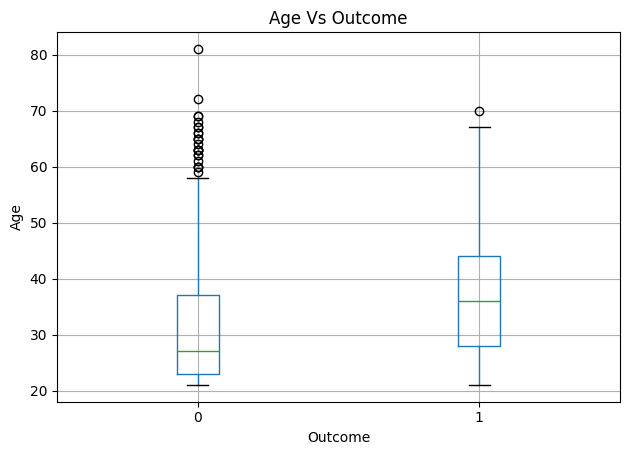

In [ ]:
important_feature = [
   'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

for col in important_feature:
  df.boxplot(column = col, by= 'Outcome')
  plt.title(f'{col} Vs Outcome')
  plt.suptitle('')
  plt.xlabel('Outcome')
  plt.ylabel(col)
  plt.tight_layout()
  plt.show()



# Analysis the correlation via heatmap

In [ ]:
#Correlation analysis
correlation = df.corr()
print(
    correlation['Outcome'].sort_values(ascending= False)
)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


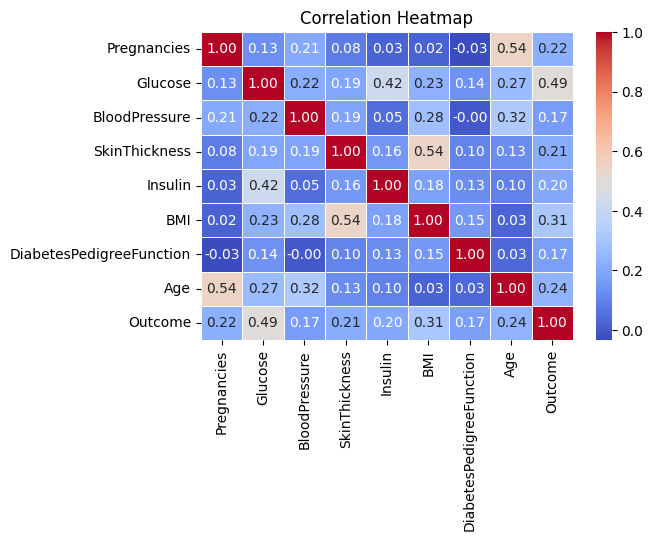

In [ ]:
import seaborn as sns
plt.figure(figsize= (6,4))

sns.heatmap(
    correlation,
    annot = True,
    cmap= 'coolwarm',
    linewidths = 0.5, fmt= '.2f')

plt.title('Correlation Heatmap')
plt.show()

# Counting the outliers in IQR method

In [ ]:
from numpy._core.defchararray import lower
#Counting Outlier in IQR Method
features = [
     'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

for col in features:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df(col) < lower_bound) | (df[col] > upper_bound)]
  print(f'Number of outliers in {col} is {len(outliers)}')

Number of outliers in Glucose is 0
Number of outliers in BloodPressure is 14
Number of outliers in SkinThickness is 87
Number of outliers in Insulin is 346
Number of outliers in BMI is 8
Number of outliers in DiabetesPedigreeFunction is 29
Number of outliers in Age is 9


# Finding out the skewness of data from variable and data transformation done using Log transformation

In [ ]:
skewness = df.drop('Outcome', axis = 1).skew()

print(skewness.sort_values(ascending = False))

Insulin                     3.380019
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
SkinThickness               0.837608
BMI                         0.599233
Glucose                     0.535587
BloodPressure               0.141885
dtype: float64


In [ ]:
#AS insulin,age, pregnencies are heavily skewed we will use Log Transformer

df['insulin_log'] = np.log1p(df['Insulin'])

df['Age_log'] = np.log1p(df['Age'])

df['Pregnancies_log'] = np.log1p(df['Pregnancies'])

df['DiabetesPedigreeFunction_log'] = np.log1p(df['DiabetesPedigreeFunction'])

df['BMI_log'] = np.log1p(df['BMI'])


print(
    df[
        [
            'insulin_log', 'Age_log', 'Pregnancies_log', 'DiabetesPedigreeFunction_log', 'BMI_log'
        ]
    ].skew()
)

insulin_log                    -0.175078
Age_log                         0.614664
Pregnancies_log                -0.243478
DiabetesPedigreeFunction_log    0.746023
BMI_log                        -0.217126
dtype: float64


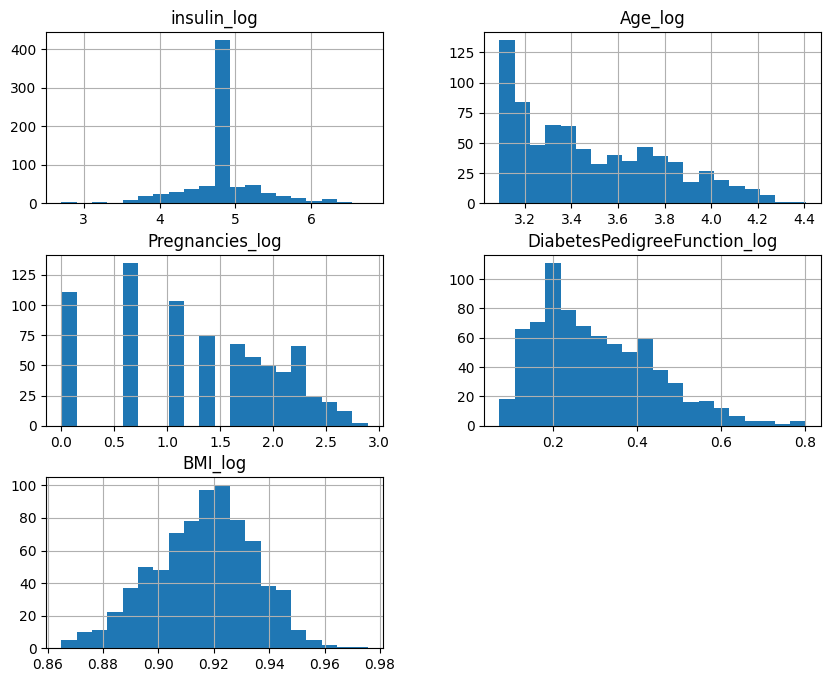

In [ ]:
df[
    [
        'insulin_log', 'Age_log', 'Pregnancies_log', 'DiabetesPedigreeFunction_log', 'BMI_log'
    ]
    ].hist(figsize= (10,8), bins = 20)
plt.tight_layout
plt.show()



# Make a copy of the modified dataset for ML training

In [ ]:
#Making the modified dataset now'

df_model = df.copy()

df_model['Insulin'] = df_model['insulin_log']
df_model['Age'] = df_model['Age_log']
df_model['Pregnancies'] = df_model['Pregnancies_log']
df_model['DiabetesPedigreeFunction'] = df_model['DiabetesPedigreeFunction_log']
df_model['BMI'] = df_model['BMI_log']

df_model.drop(
    columns= [
        'insulin_log', 'Age_log', 'Pregnancies_log', 'DiabetesPedigreeFunction_log', 'BMI_log'
    ], inplace = True
)

print(df_model.shape)
print(df_model.columns)

(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


# Select variables and target for model training

In [ ]:
#Target selection
X = df_model.drop('Outcome' , axis= 1)
y = df_model['Outcome']

In [ ]:
#Splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y)

print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


# Standard Scaling

In [ ]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

X_train_scaled


array([[-0.81272902, -1.05642747, -0.82674004, ..., -0.71862663,
         0.52472236, -0.84682277],
       [ 0.63196853,  0.14439907,  0.47777235, ..., -0.30580255,
         0.0433427 ,  0.72771799],
       [-0.27953414, -0.55608308, -1.15286813, ...,  0.47147744,
        -0.8688718 , -0.72198938],
       ...,
       [-0.81272902, -0.82293342, -0.17448384, ...,  0.8715997 ,
        -0.9035499 , -0.1621569 ],
       [ 1.42904946, -0.35594533, -0.17448384, ..., -0.66452877,
        -1.31089003,  0.72771799],
       [ 0.39221196,  0.74481233, -1.15286813, ..., -0.32214051,
        -0.57676647,  0.48586674]])

# Model Training is done using Logistic Regression

In [ ]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter = 1000,
    random_state = 42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:,1]



# Model Evaluation. Testing accuracy, precision, recall, F1 score, ROC-AUC score, confusion matrix and classification report

In [ ]:
#Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('ROC AUC Score:', roc_auc_score(y_test, y_prob))

print('Confusion Matrix:', confusion_matrix(y_test, y_pred))
print('Classification Report:', classification_report(y_test, y_pred))

Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1 Score: 0.5454545454545454
ROC AUC Score: 0.8190740740740741
Confusion Matrix: [[82 18]
 [27 27]]
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



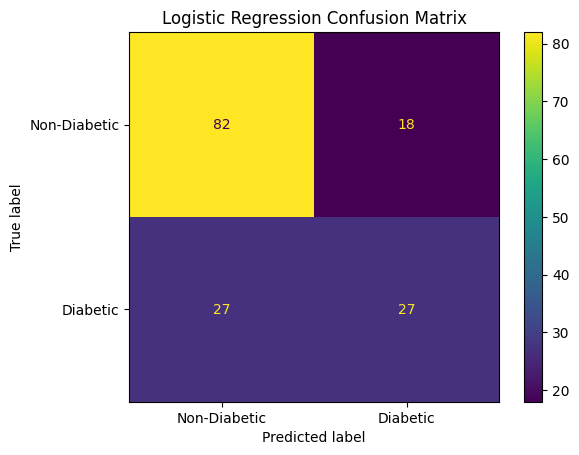

In [ ]:
#Graphical presentation

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels= ['Non-Diabetic', 'Diabetic'])

plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Final leakage free model pipeline building

In [ ]:
#FINAL LEAKAGE FREE MODELLING PIPELINE
url2 = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'

data = pd.read_csv(url2)
print(data.shape)

(768, 9)


# Pre processing before creating the pipeline

In [ ]:
#Important pre processing
invalid_zero_cols = [
    'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'
]
data[invalid_zero_cols] = data[invalid_zero_cols].replace(0, np.nan)
print(data[invalid_zero_cols].isnull().sum())


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


# Selecting variables and target

In [ ]:
X = data.drop('Outcome', axis = 1)
y = data['Outcome']

In [ ]:
#splitting train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y)

print('Training Set:', X_train.shape)
print('Testing Set:', X_test.shape)

print('Training Outcome Distribution', y_train.value_counts(normalize= True))
print('Testing Outcome Distribution', y_test.value_counts(normalize= True))


Training Set: (614, 8)
Testing Set: (154, 8)
Training Outcome Distribution Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Testing Outcome Distribution Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


# Creating the leakage free pipleline

In [ ]:
#Proper preprocessing pipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter = 1000, random_state = 42))
])



# Model training using logistic regression pipeline

In [ ]:
logistic_pipeline.fit(X_train, y_train)

y_pred_new = logistic_pipeline.predict(X_test)
y_prob_new = logistic_pipeline.predict_proba(X_test)[:,1]

# Second time evaluation of leakage free model training

In [ ]:
#New Baseline Evaluation

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

print('Accuracy:', accuracy_score(y_test, y_pred_new))
print('Precision:', precision_score(y_test, y_pred_new))
print('Recall:', recall_score(y_test, y_pred_new))
print('F1 Score:', f1_score(y_test, y_pred_new))
print('ROC AUC Score:', roc_auc_score(y_test, y_prob_new))

print('Confusion Matrix:', confusion_matrix(y_test, y_pred_new))
print('Classification Report:', classification_report(y_test, y_pred_new))


Accuracy: 0.7012987012987013
Precision: 0.5909090909090909
Recall: 0.48148148148148145
F1 Score: 0.5306122448979592
ROC AUC Score: 0.8183333333333334
Confusion Matrix: [[82 18]
 [28 26]]
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



In [ ]:
print(logistic_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


# Analysis the accuracy, precision, recall, F1 score, confusion matrix in different thresholds

In [ ]:
#Threshold analysis
threshold_to_test= [
    0.30,
    0.35,
    0.40,
    0.45,
    0.55,
    0.60
]

for threshold in threshold_to_test:
  y_pred_new_threshold = (y_prob_new >= threshold).astype(int)

  print(f'\nThreshold: {threshold}')
  print('Precision:', round(precision_score(y_test, y_pred_new_threshold), 3))
  print('Recall:', round(recall_score(y_test, y_pred_new_threshold), 3))
  print('F1 Score:', round(f1_score(y_test, y_pred_new_threshold), 3))
  print('Accuracy:', round(accuracy_score(y_test, y_pred_new_threshold), 3))
  print('Confusion Matrix:', confusion_matrix(y_test, y_pred_new_threshold))



Threshold: 0.3
Precision: 0.595
Recall: 0.815
F1 Score: 0.688
Accuracy: 0.74
Confusion Matrix: [[70 30]
 [10 44]]

Threshold: 0.35
Precision: 0.585
Recall: 0.704
F1 Score: 0.639
Accuracy: 0.721
Confusion Matrix: [[73 27]
 [16 38]]

Threshold: 0.4
Precision: 0.621
Recall: 0.667
F1 Score: 0.643
Accuracy: 0.74
Confusion Matrix: [[78 22]
 [18 36]]

Threshold: 0.45
Precision: 0.608
Recall: 0.574
F1 Score: 0.59
Accuracy: 0.721
Confusion Matrix: [[80 20]
 [23 31]]

Threshold: 0.55
Precision: 0.619
Recall: 0.481
F1 Score: 0.542
Accuracy: 0.714
Confusion Matrix: [[84 16]
 [28 26]]

Threshold: 0.6
Precision: 0.684
Recall: 0.481
F1 Score: 0.565
Accuracy: 0.74
Confusion Matrix: [[88 12]
 [28 26]]


# Tabulize sensitivity and specificity

In [ ]:
#Sensitivity and Specificity Table

from sklearn.metrics import confusion_matrix
thresholds = [0.30,0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for threshold in thresholds:
  y_pred_new_threshold = (y_prob_new >= threshold).astype(int)

  tn,fp,fn,tp = confusion_matrix(y_test, y_pred_new_threshold).ravel()

  sensitivity = tp / (tp + fn)
  specificity = tn / (tn + fp)

  results.append({
      'Threshold': threshold,
      'Sensitivity': sensitivity,
      'Specificity': specificity,
      'False Negatives': fn,
      'False Positives': fp,
  })

threshold_table = pd.DataFrame(results)

threshold_table


,Threshold,Sensitivity,Specificity,False Negatives,False Positives
0,0.30,0.814815,0.70,10,30
1,0.35,0.703704,0.73,16,27
2,0.40,0.666667,0.78,18,22
3,0.45,0.574074,0.80,23,20
4,0.50,0.481481,0.82,28,18
5,0.55,0.481481,0.84,28,16
6,0.60,0.481481,0.88,28,12


# Cross validation using Stratified K-Fold

In [ ]:
#Cross Validation
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# Measuring Mean ROC-AUC Scores

In [ ]:
from sklearn.model_selection import cross_val_score

cv_auc_scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv= cv,
    scoring = 'roc_auc'
)

print('ROC-AUC scores:', cv_auc_scores)
print('Mean ROC-AUC:', cv_auc_scores.mean())
print('Standard Deviation:', cv_auc_scores.std())

ROC-AUC scores: [0.83851852 0.87703704 0.84481481 0.83075472 0.81188679]
Mean ROC-AUC: 0.8406023759608665
Standard Deviation: 0.021312591368774725


# Measuring mean Recall

In [ ]:
#recall cross validation
cv_recall_scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv= cv,
    scoring = 'recall'
)

print('Recall scores:', cv_recall_scores)
print('Mean Recall:', cv_recall_scores.mean())
print('Standard Deviation:', cv_recall_scores.std())


Recall scores: [0.62962963 0.55555556 0.53703704 0.50943396 0.62264151]
Mean Recall: 0.5708595387840671
Standard Deviation: 0.04751120086942186


# Measuring mean accuracy

In [ ]:
#Accuracy cross validation
cv_accuracy_scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv= cv,
    scoring = 'accuracy'
)

print('Accuracy scores:', cv_accuracy_scores)
print('Mean Accuracy:', cv_accuracy_scores.mean())
print('Standard Deviation:', cv_accuracy_scores.std())

Accuracy scores: [0.77922078 0.78571429 0.75324675 0.74509804 0.75163399]
Mean Accuracy: 0.7629827688651218
Standard Deviation: 0.016271713153707835


# Comparing via model training the dataset with random forest model

In [ ]:
#Random forest model
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators= 200,
        random_state= 42,
        class_weight= 'balanced'))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

print('Random Forest')

print('Accuracy:', accuracy_score(y_test, rf_pred))
print('Precision:', precision_score(y_test, rf_pred))
print('Recall:', recall_score(y_test, rf_pred))
print('F1 Score:', f1_score(y_test, rf_pred))
print('ROC AUC Score:', roc_auc_score(y_test, rf_prob))

print('Confusion Matrix:', confusion_matrix(y_test, rf_pred))
print('Classification Report:', classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.7467532467532467
Precision: 0.6595744680851063
Recall: 0.5740740740740741
F1 Score: 0.6138613861386139
ROC AUC Score: 0.8136111111111112
Confusion Matrix: [[84 16]
 [23 31]]
Classification Report:               precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



# Comparing via model training the dataset with SVM model

In [ ]:
#SVM ML
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler()),
    ('model', SVC(
        probability= True,
        random_state=42,
        class_weight= 'balanced'))
])

svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)
svm_prob = svm_pipeline.predict_proba(X_test)[:,1]

print('SVM')

print('Accuracy:', accuracy_score(y_test, svm_pred))
print('Precision:', precision_score(y_test, svm_pred))
print('Recall:', recall_score(y_test, svm_pred))
print('F1 Score:', f1_score(y_test, svm_pred))
print('ROC AUC Score:', roc_auc_score(y_test, svm_prob))

print('Confusion Matrix:', confusion_matrix(y_test, svm_pred))
print('Classification Report:', classification_report(y_test, svm_pred))

SVM
Accuracy: 0.7337662337662337
Precision: 0.6
Recall: 0.7222222222222222
F1 Score: 0.6554621848739496
ROC AUC Score: 0.8103703703703704
Confusion Matrix: [[74 26]
 [15 39]]
Classification Report:               precision    recall  f1-score   support

           0       0.83      0.74      0.78       100
           1       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



# Creating the comparison table for all three model training metrics

In [ ]:
#COMPARISON TABLE
comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_score(y_test, y_pred_new), accuracy_score(y_test, rf_pred), accuracy_score(y_test, svm_pred)],
    'Precision': [precision_score(y_test, y_pred_new), precision_score(y_test, rf_pred), precision_score(y_test, svm_pred)],
    'Recall': [recall_score(y_test, y_pred_new), recall_score(y_test, rf_pred), recall_score(y_test, svm_pred)],
    'F1 Score': [f1_score(y_test, y_pred_new), f1_score(y_test, rf_pred), f1_score(y_test, svm_pred)],
    'ROC AUC Score': [roc_auc_score(y_test, y_prob_new), roc_auc_score(y_test, rf_prob), roc_auc_score(y_test, svm_prob)]
})

comparison_table.round(30)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Logistic Regression,0.701299,0.590909,0.481481,0.530612,0.818333
1,Random Forest,0.746753,0.659574,0.574074,0.613861,0.813611
2,SVM,0.733766,0.600000,0.722222,0.655462,0.810370


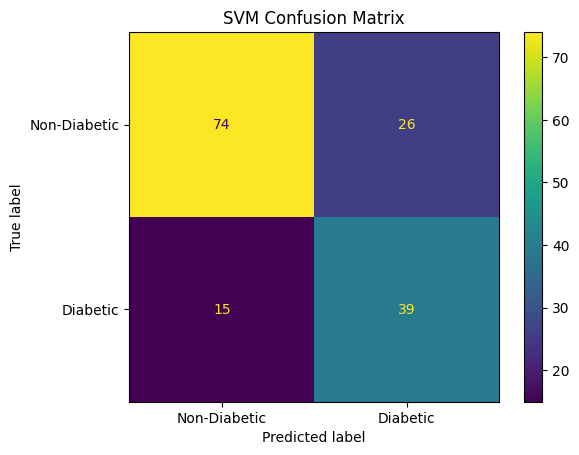

In [ ]:
ConfusionMatrixDisplay.from_predictions( y_test, svm_pred, display_labels= ['Non-Diabetic', 'Diabetic'])

plt.title('SVM Confusion Matrix')
plt.show()

# Final Model Comparison

Among the tested models, SVM achieved the highest recall and F1-score, while logistic regression achieved the highest ROC-AUC. These results highlight the trade off between overall discrimination and sensitivity in diabetes risk prediction.

# Conclusion

This project demonstrates a complete mavchine learning workflow for diabetes risk classification, including data preprocessing, exploratory analysis, model training and evaluation. The results show that model selection in healthcare should consider clinically relevant metrics such as recall, not accuracy alone.